## _PyG to NetworkX_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
from tqdm import tqdm
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data

In [5]:
pp = pprint.PrettyPrinter(indent=2)

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _Input Data_

In [7]:
# Read Event from the Testset
inputdir="run/gnn_processed/test"
outputdir="run/stt2_trkx/trkx_from_cc"
os.makedirs(outputdir, exist_ok=True)

In [8]:
all_files = glob.glob(os.path.join(inputdir, "*"))
all_files = sorted(all_files)
print("Total Test Events: ", len(all_files))

Total Test Events:  479


In [9]:
all_files[:10]

['run/gnn_processed/test/1012',
 'run/gnn_processed/test/1052',
 'run/gnn_processed/test/1055',
 'run/gnn_processed/test/1064',
 'run/gnn_processed/test/108',
 'run/gnn_processed/test/1081',
 'run/gnn_processed/test/110',
 'run/gnn_processed/test/1103',
 'run/gnn_processed/test/1109',
 'run/gnn_processed/test/1112']

In [10]:
# Use One Event
filename = all_files[1]
data = torch.load(filename, map_location=device)
evtid = int(os.path.basename(filename))
print("evtid: ", evtid)

evtid:  1052


In [11]:
print(data.keys)

['x', 'modulewise_true_edges', 'edge_index', 'event_file', 'layerwise_true_edges', 'layers', 'y', 'hid', 'y_pid', 'scores', 'cell_data', 'pid', 'pt']


In [12]:
data.num_nodes, data.num_edges, data.num_features

(169, 2, 3)

In [13]:
data.is_directed()

True

In [14]:
'edge_attr' in data

False

In [15]:
# for key, item in data:
#    print(f'{key}, {item} found in Data')

In [16]:
data

Data(x=[169, 3], pid=[169], layers=[169], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000001052', hid=[169], pt=[169], modulewise_true_edges=[2, 163], layerwise_true_edges=[2, 642], edge_index=[2, 1065], y=[1065], cell_data=[169, 1], y_pid=[1065], scores=[2130])

In [17]:
# data.x == data['x']

- see https://stackoverflow.com/questions/19984102/select-elements-of-numpy-array-via-boolean-mask-array

In [18]:
# true edges
true_edges = data.edge_index[:, data.y_pid]
true_edges.shape

torch.Size([2, 537])

In [19]:
# true edges
false_edges = data.edge_index[:, ~data.y_pid]
false_edges.shape

torch.Size([2, 528])

### _(a) - Method 1: PyG to NetworkX_

Using `to_networkx()` from `torch_geometric.utils`.

In [20]:
import networkx as nx
from torch_geometric.utils import to_networkx

In [21]:
# from https://github.com/exatrkx/exatrkx-neurips19/blob/master/gnn-tracking/heptrkx/nx_graph/utils_plot.py
def get_pos(Gp):
    pos = {}
    for node in Gp.nodes():
        # r, phi, z = Gp.node[node]['pos'][:3]
        r,phi = G.nodes[node]['x'][:2]
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        pos[node] = np.array([x, y])
    return pos

def plot_networkx(G, ax=None, only_true=False):
    """G is networkx graph,
    node feature: {'pos': [r, phi, z]}
    edge feature: {"solution": []}
    """
    if ax is None:
        fig, ax = plt.subplots()

    n_edges = len(G.edges())
    edge_colors = [0.]*n_edges
    true_edges = []
    for iedge,edge in enumerate(G.edges(data=True)):
        if int(edge[2]['y_pid']) == 1:
            edge_colors[iedge] = 'r'
            true_edges.append((edge[0], edge[1]))
        else:
            edge_colors[iedge] = 'grey'

    Gp = nx.edge_subgraph(G, true_edges) if only_true else G
    edge_colors = ['k']*len(true_edges) if only_true else edge_colors 

    pos = get_pos(Gp)

    nx.draw(Gp, pos, node_color='#A0CBE2', edge_color=edge_colors,
       width=0.5, with_labels=False, node_size=1, ax=ax, arrows=False)

In [22]:
# Data is a DiGraph i.e. G := DiGraph()
# G = to_networkx(data)
G = to_networkx(data, node_attrs=['x'], edge_attrs=['scores', 'y_pid'])

In [23]:
# Shows nodes with attributes e.g. attrs = x [x,y,ir]
# G.nodes(data=True)
# G.nodes.data()[0]

In [24]:
# Shows edges with attributes e.g (edges, {attrs}) >> (0, 10, {'scores': .., 'y_pid': ..})
# G.edges(data=True)
# G.edges.data()
# G.edges.data("scores")

In [25]:
G.in_edges == G.out_edges

True

In [26]:
# plot_networkx(G)

- Components Methods for DiGraphs
- DiGraph has `weakly` or `strongly` connected components

In [27]:
# Strongly Connected Components (SCCs)
print("strongly_connected: ", nx.is_strongly_connected(G))

strongly_connected:  False


In [28]:
# Weakly Connected Components (WCCs)
print("weakly_connected: ", nx.is_weakly_connected(G))

weakly_connected:  True


In [29]:
# WCC from DiGraph
# clusters = list(map(lambda g: g, nx.weakly_connected_components(G)))
# clusters = [g for g in nx.weakly_connected_components(G)]

In [30]:
# OR use loop to build list
clusters = []
for g in nx.weakly_connected_components(G):
    clusters.append(g)
    print(g, "\n")

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168} 



### _(b) - Method 2: PyG to NetworkX_

Using `add_weighted_edges_from()` from the NetworkX for a `DiGraph()`

In [31]:
# DiGraph
G = nx.DiGraph()

In [32]:
scores = data.scores[:data.edge_index.shape[1]].cpu().detach().numpy()  # score has twice the size of edge_index (flip(0) was used)
senders = data.edge_index[0].cpu().detach().numpy()
receivers = data.edge_index[1].cpu().detach().numpy()

In [33]:
senders.shape, receivers.shape, scores.shape

((1065,), (1065,), (1065,))

In [34]:
type(senders), type(receivers), type(scores)

(numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [35]:
senders[:5]

array([0, 1, 1, 2, 2])

In [36]:
receivers[:5]

array([1, 2, 3, 4, 5])

In [37]:
scores[:5]

array([0.99966836, 0.9998111 , 0.00440025, 0.9998111 , 0.00348641],
      dtype=float32)

In [38]:
# Create list of tuples '(u, v, w)' from senders, receivers and scores ndarrays
elist = list(map(lambda u, v, w:(u, v, w), senders, receivers, scores))

In [39]:
elist[:5]

[(0, 1, 0.99966836),
 (1, 2, 0.9998111),
 (1, 3, 0.0044002505),
 (2, 4, 0.9998111),
 (2, 5, 0.00348641)]

In [40]:
G.edges

OutEdgeView([])

In [41]:
G.edges.items()

ItemsView(OutEdgeView([]))

In [42]:
G.edges.values()

ValuesView(OutEdgeView([]))

In [43]:
G.edges.data()

OutEdgeDataView([])

In [44]:
# Doesn't work
# nx.is_weakly_connected(G)

In [45]:
clusters = []
for g in nx.weakly_connected_components(G):
    clusters.append(g)
    print(g, "\n")

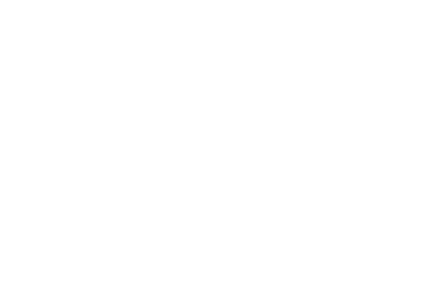

In [46]:
# Draw Graph
# nx.draw(G, with_labels=True)
nx.draw(G)
plt.show()